# Multi Attribute Analysis


Multi-attribute analysis in seismic interpretation combines multiple seismic attributes—such as amplitude, frequency, phase, and inversion results—to enhance detection of geological features, thin beds, and hydrocarbon reservoirs. It uses statistical techniques (e.g., neural networks, crossplotting) and machine learning (e.g., Self-Organizing Maps - SOM) to move beyond single-attribute limitations, improving reservoir characterization and reducing exploration risk

In [8]:
import numpy as np 
import segyio 
import bruges as bg
import matplotlib.pyplot as plt


In [6]:
seismic_file=np.load("../../data/raw/seismic/156_iline.npy")
# seismic_file=segyio.read("/home/ashraf/Downloads/ST8511r92.segy)
seismic_file.shape


(227, 301)

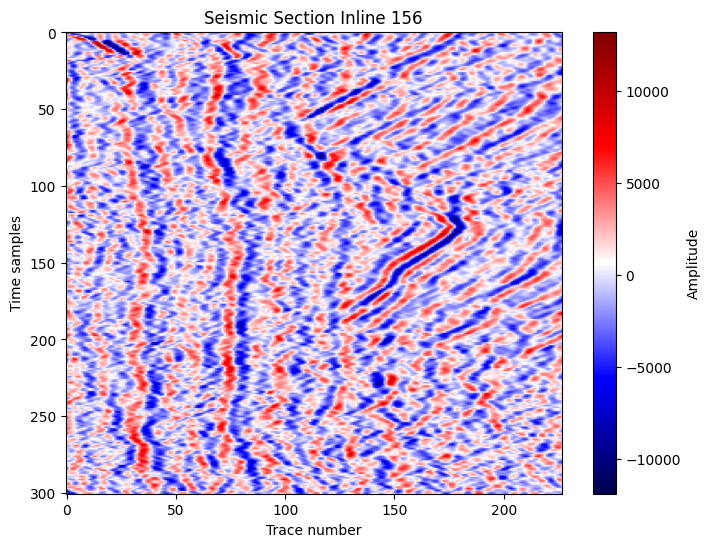

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(seismic_file.T,
           cmap="seismic",
           aspect="auto")

plt.xlabel("Trace number")
plt.ylabel("Time samples")
plt.title("Seismic Section Inline 156")

plt.colorbar(label="Amplitude")

plt.show()


In [9]:
env=bg.attribute.envelope(seismic_file)
env.shape

(227, 301)

Text(0.5, 1.0, 'Envelope Attribute')

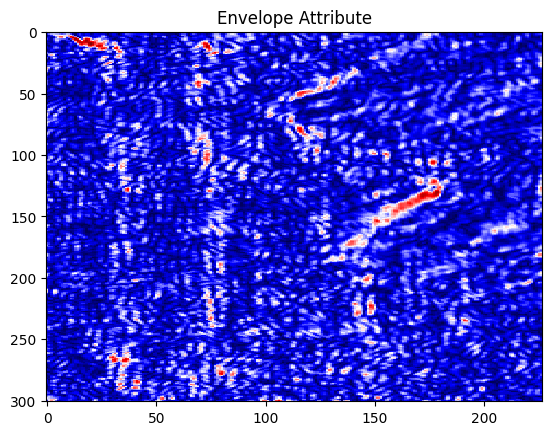

In [13]:
plt.imshow(env.T,interpolation="none",cmap="seismic",aspect="auto")
plt.title("Envelope Attribute")

In [ ]:
env=bg.attribute.envelope(seismic_file)
inst_phase=bg.attribute.instantaneous_phase(seismic_file)
inst_freq=bg.attribute.instantaneous_frequency(seismic_file,dt=0.004)


## Build Feature Matrix

In [19]:
# Now we have to convert 2D Seismic to ML Format

#Flatten all attribute
env_flat=env.flatten()
inst_phase_flat=inst_phase.flatten()
inst_freq_flat=inst_freq.flatten()

In [24]:
# # Make same size (due to diff)
min_len=min(len(env_flat),len(inst_phase_flat),len(inst_freq_flat))

X=np.vstack([
    env_flat[:min_len],
    inst_phase_flat[:min_len],
    inst_freq_flat[:min_len]
]).T
print(X.shape)  # (samples, features)

(68026, 3)


## Normalize Data (IMPORTANT)

In [28]:
from sklearn.preprocessing import StandardScaler

In [27]:
pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 1.8 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 961.5 kB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.
